<a href="https://colab.research.google.com/github/P-Karthikeya512/Rock-segmentation/blob/main/Baseline_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import glob
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model

from sklearn.model_selection import train_test_split

# =========================
# CONFIG
# =========================
IMG_SIZE = (256, 256)
BATCH_SIZE = 4
EPOCHS = 50
SEED = 42

IMAGE_DIR = "/content/drive/MyDrive/dataset_rock/images"
MASK_DIR  = "/content/drive/MyDrive/dataset_rock/masks"

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("Images :", len(os.listdir(IMAGE_DIR)))
print("Masks  :", len(os.listdir(MASK_DIR)))

print(os.listdir(IMAGE_DIR)[:5])
print(os.listdir(MASK_DIR)[:5])


Images : 16
Masks  : 16
['image5.jpg', 'image10.jpg', 'image16.png', 'image1.jpg', 'image4.jpg']
['image2.png', 'image7.png', 'image9.png', 'image11.png', 'image3.png']


In [2]:
def get_pairs(image_dir, mask_dir):
    image_paths = []
    for ext in ["jpg", "jpeg", "png", "bmp", "tif", "tiff"]:
        image_paths.extend(glob.glob(os.path.join(image_dir, f"*.{ext}")))

    image_paths = sorted(image_paths)

    mask_map = {}
    for ext in ["jpg", "jpeg", "png", "bmp", "tif", "tiff"]:
        for p in glob.glob(os.path.join(mask_dir, f"*.{ext}")):
            stem = os.path.splitext(os.path.basename(p))[0]
            mask_map[stem] = p

    pairs = []
    for img_path in image_paths:
        stem = os.path.splitext(os.path.basename(img_path))[0]
        if stem in mask_map:
            pairs.append((img_path, mask_map[stem]))
        else:
            print(f"Warning: no mask found for {img_path}")

    return pairs

pairs = get_pairs(IMAGE_DIR, MASK_DIR)
print("Total paired samples:", len(pairs))

# =========================
# LOAD ONE IMAGE + MASK
# =========================
def load_image_mask(img_path, mask_path):
    # Image
    img = cv2.imread(img_path.decode(), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0

    # Mask
    mask = cv2.imread(mask_path.decode(), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise ValueError(f"Could not read mask: {mask_path}")
    mask = cv2.resize(mask, IMG_SIZE, interpolation=cv2.INTER_NEAREST)

    # Binary mask: 0/1
    mask = (mask > 127).astype(np.float32)
    mask = np.expand_dims(mask, axis=-1)

    return img, mask

def tf_load_image_mask(img_path, mask_path):
    img, mask = tf.numpy_function(
        func=load_image_mask,
        inp=[img_path, mask_path],
        Tout=[tf.float32, tf.float32]
    )
    img.set_shape([IMG_SIZE[0], IMG_SIZE[1], 3])
    mask.set_shape([IMG_SIZE[0], IMG_SIZE[1], 1])
    return img, mask

# =========================
# AUGMENTATION
# =========================
def augment(image, mask):
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    k = tf.random.uniform((), minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    mask = tf.image.rot90(mask, k)

    return image, mask

# =========================
# CREATE DATASET
# =========================

pairs = get_pairs(IMAGE_DIR, MASK_DIR)

print("Total paired samples:", len(pairs))

for img, mask in pairs[:3]:
    print(img)
    print(mask)
    print()


Total paired samples: 16
Total paired samples: 16
/content/drive/MyDrive/dataset_rock/images/image1.jpg
/content/drive/MyDrive/dataset_rock/masks/image1.png

/content/drive/MyDrive/dataset_rock/images/image10.jpg
/content/drive/MyDrive/dataset_rock/masks/image10.png

/content/drive/MyDrive/dataset_rock/images/image11.png
/content/drive/MyDrive/dataset_rock/masks/image11.png



Train samples: 12
Val samples: 4


Model: "UNet_Binary"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64,    │          0 │ max_pooling2d_1[

 Total params: 7,771,873 (29.65 MB)

 Trainable params: 7,765,985 (29.62 MB)

 Non-trainable params: 5,888 (23.00 KB)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.3593 - dice_coef: 0.4471 - iou_coef: 0.2880 - loss: 0.5529 
Epoch 1: val_dice_coef improved from None to 0.50368, saving model to best_unet.keras

Epoch 1: finished saving model to best_unet.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.3656 - dice_coef: 0.4488 - iou_coef: 0.2894 - loss: 0.5512 - val_accuracy: 0.4410 - val_dice_coef: 0.5037 - val_iou_coef: 0.3366 - val_loss: 0.4963 - learning_rate: 1.0000e-04
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.3959 - dice_coef: 0.4660 - iou_coef: 0.3038 - loss: 0.5340
Epoch 2: val_dice_coef did not improve from 0.50368
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.3980 - dice_coef: 0.4684 - iou_coef: 0.3059 - loss: 0.5316 - val_accuracy: 0.4446 - val_dice_coef: 0.5009 - val_iou_coef: 0.3341 - val_loss: 0.4991 - learning_rate: 1.0000e-04
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 852ms/step - accuracy: 0.4369 - dice_coef: 0.4818 - iou_coef: 0.3175 - lo

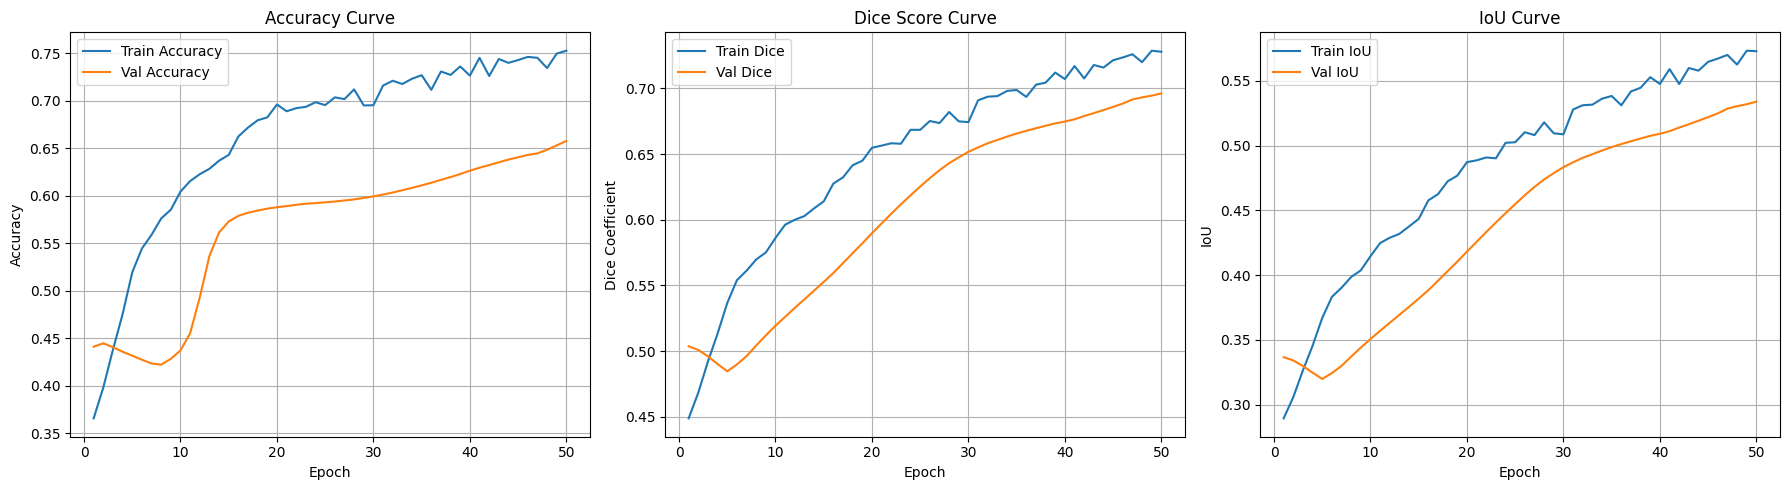

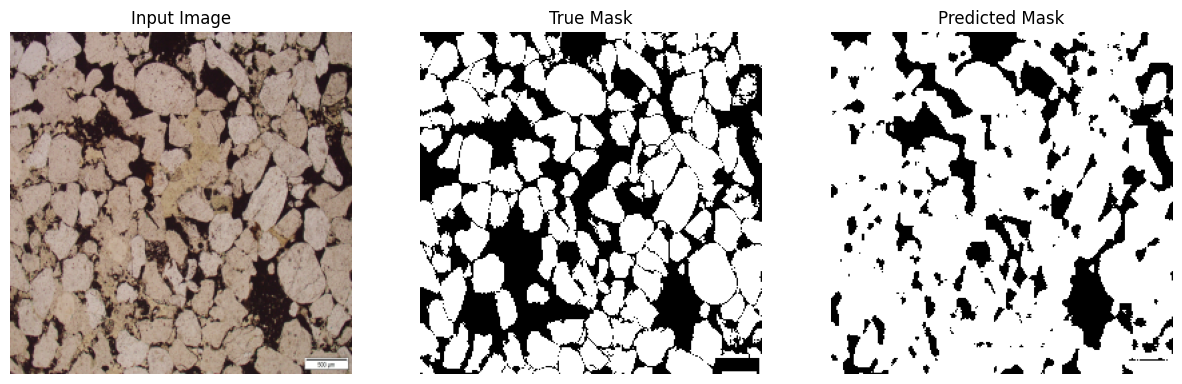

In [3]:
def make_dataset(pairs, training=True):
    img_paths = [p[0] for p in pairs]
    mask_paths = [p[1] for p in pairs]

    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    if training:
        ds = ds.shuffle(buffer_size=len(pairs), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(tf_load_image_mask, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_pairs, val_pairs = train_test_split(pairs, test_size=0.2, random_state=SEED)

train_ds = make_dataset(train_pairs, training=True)
val_ds = make_dataset(val_pairs, training=False)

print("Train samples:", len(train_pairs))
print("Val samples:", len(val_pairs))

# =========================
# METRICS / LOSS
# =========================
def dice_coef(y_true, y_pred, smooth=1e-7):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def iou_coef(y_true, y_pred, smooth=1e-7):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# =========================
# U-NET BUILDING BLOCKS
# =========================
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def down_block(x, filters):
    c = conv_block(x, filters)
    p = layers.MaxPool2D((2, 2))(c)
    p = layers.Dropout(0.2)(p)
    return c, p

def up_block(x, skip, filters):
    x = layers.Conv2DTranspose(filters, 2, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, skip])
    x = layers.Dropout(0.2)(x)
    x = conv_block(x, filters)
    return x

# =========================
# BUILD U-NET
# =========================
def build_unet(input_shape=(256, 256, 3)):
    inputs = layers.Input(shape=input_shape)

    s1, p1 = down_block(inputs, 32)
    s2, p2 = down_block(p1, 64)
    s3, p3 = down_block(p2, 128)
    s4, p4 = down_block(p3, 256)

    bottleneck = conv_block(p4, 512)

    u1 = up_block(bottleneck, s4, 256)
    u2 = up_block(u1, s3, 128)
    u3 = up_block(u2, s2, 64)
    u4 = up_block(u3, s1, 32)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(u4)

    model = Model(inputs, outputs, name="UNet_Binary")
    return model

model = build_unet()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=["accuracy", dice_coef, iou_coef]
)

model.summary()

# =========================
# CALLBACKS
# =========================
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_unet.keras",
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_dice_coef",
        mode="max",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_dice_coef",
        mode="max",
        factor=0.5,
        patience=4,
        verbose=1
    )
]

# =========================
# TRAIN
# =========================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# =========================
# PLOTS: ACCURACY, DICE, IOU
# =========================
def plot_training_curves(history):
    hist = history.history
    epochs_range = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(18, 5))

    # Accuracy
    plt.subplot(1, 3, 1)
    plt.plot(epochs_range, hist["accuracy"], label="Train Accuracy")
    plt.plot(epochs_range, hist["val_accuracy"], label="Val Accuracy")
    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    # Dice Score
    plt.subplot(1, 3, 2)
    plt.plot(epochs_range, hist["dice_coef"], label="Train Dice")
    plt.plot(epochs_range, hist["val_dice_coef"], label="Val Dice")
    plt.title("Dice Score Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Dice Coefficient")
    plt.legend()
    plt.grid(True)

    # IoU
    plt.subplot(1, 3, 3)
    plt.plot(epochs_range, hist["iou_coef"], label="Train IoU")
    plt.plot(epochs_range, hist["val_iou_coef"], label="Val IoU")
    plt.title("IoU Curve")
    plt.xlabel("Epoch")
    plt.ylabel("IoU")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_curves(history)

# =========================
# PREDICTION + VISUALIZATION
# =========================
def show_prediction(model, pair):
    img_path, mask_path = pair
    img, mask = load_image_mask(img_path.encode(), mask_path.encode())

    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)[0]
    pred_mask = (pred > 0.5).astype(np.uint8)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask.squeeze(), cmap="gray")
    plt.title("True Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask.squeeze(), cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.show()

# Show one validation sample
show_prediction(model, val_pairs[0])